In [184]:
import pandas as pd 

df = pd.read_csv(r"E:\Pyhton code\Data Sets\archive\mall customer data\Mall_Customers.csv")

print(df.head())
print(df.info())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


In [185]:
X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]

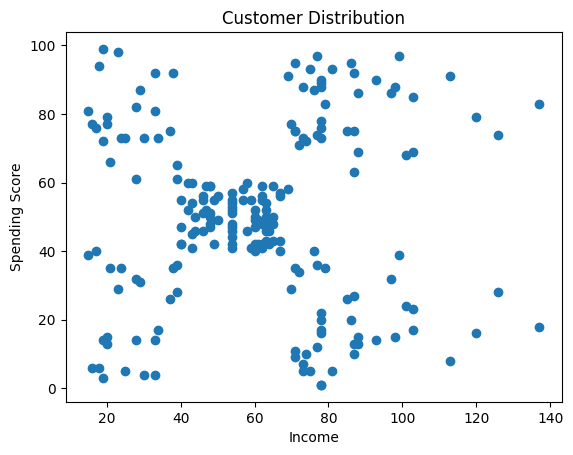

In [186]:
import matplotlib.pyplot as plt

plt.scatter(X["Annual Income (k$)"], X["Spending Score (1-100)"])
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Customer Distribution")
plt.show()

In [187]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

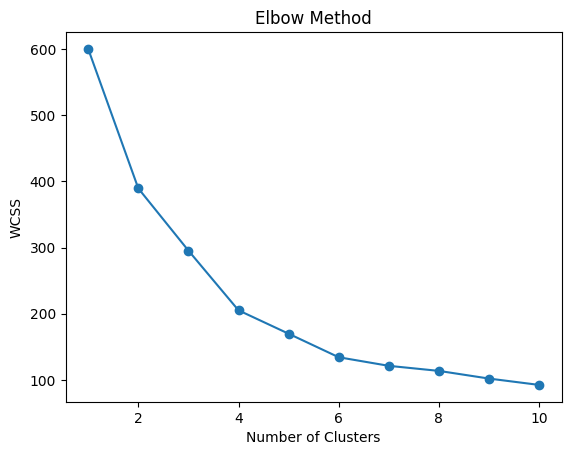

In [188]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)
    
plt.plot(range(1,11), wcss, marker = 'o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()    

In [189]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(x_scaled)
centroids = kmeans.cluster_centers_

In [190]:
import numpy as np 
distances = np.linalg.norm(x_scaled - centroids[labels], axis=1)

In [191]:
threshold = np.percentile(distances, 95)
preds = (distances > threshold).astype(int)

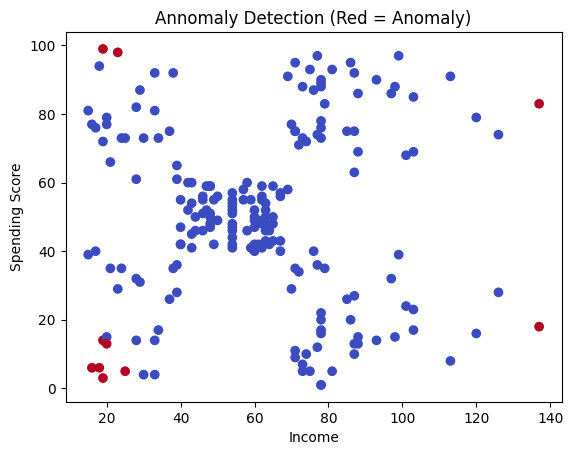

In [192]:
plt.scatter(X["Annual Income (k$)"], X["Spending Score (1-100)"], c = preds, cmap='coolwarm')
plt.xlabel("Income")
plt.ylabel("Spending Score")
plt.title("Annomaly Detection (Red = Anomaly)")
plt.show()

In [193]:
df["Anomaly"] = preds
anomalies = df[df["Anomaly"] == 1]
print(anomalies.head())

    CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
2            3  Female   20                  16                       6   
6            7  Female   35                  18                       6   
8            9    Male   64                  19                       3   
10          11    Male   67                  19                      14   
11          12  Female   35                  19                      99   

    Anomaly  
2         1  
6         1  
8         1  
10        1  
11        1  


In [194]:
from sklearn.metrics import silhouette_score
score = silhouette_score(x_scaled, labels)
print("Silhouette Score:", score)

Silhouette Score: 0.4039582785148566


In [195]:
print("Anomaly %:", np.mean(preds)*100)

Anomaly %: 5.0


In [196]:
df["spend_income_ratio"] = df["Spending Score (1-100)"] / (df["Annual Income (k$)"] + 1e-6)

In [197]:
df["income_age_ratio"] = (df["Annual Income (k$)"] / df["Age"] + 1e-6)

In [198]:
df["income_dev"] = df["Annual Income (k$)"] - df["Annual Income (k$)"].mean()
df["spend_dev"] = df["Spending Score (1-100)"] - df["Spending Score (1-100)"].mean()

In [199]:
df["behavior_score"] = df["Annual Income (k$)"] * df["Spending Score (1-100)"]

In [ ]:
# Ensure the required columns exist
if "income_dev" not in df.columns:
    df["income_dev"] = df["Annual Income (k$)"] - df["Annual Income (k$)"].mean()
if "spend_dev" not in df.columns:
    df["spend_dev"] = df["Spending Score (1-100)"] - df["Spending Score (1-100)"].mean()
if "behavior_score" not in df.columns:
    df["behavior_score"] = df["Annual Income (k$)"] * df["Spending Score (1-100)"]

X_new = df[["spend_income_ratio", "income_age_ratio", "income_dev", "spend_dev", "behavior_score"]].copy()

In [201]:
x_scaled_new = scaler.fit_transform(X_new)

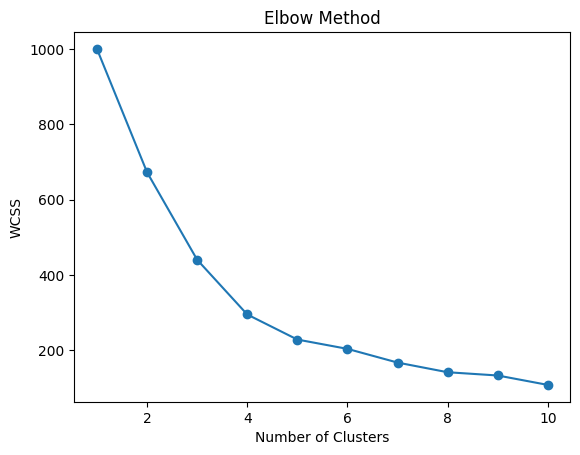

In [202]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(x_scaled_new)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [203]:
k = 6  # choose based on elbow

kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(x_scaled_new)

centroids = kmeans.cluster_centers_

In [204]:
distances = np.linalg.norm(x_scaled_new - centroids[labels], axis=1)

In [205]:
for p in [90, 92, 95, 97]:
    thresh = np.percentile(distances, p)
    preds_temp = (distances > thresh).astype(int)
    
    print(f"Threshold {p}% → Anomalies:", np.sum(preds_temp))

Threshold 90% → Anomalies: 20
Threshold 92% → Anomalies: 16
Threshold 95% → Anomalies: 10
Threshold 97% → Anomalies: 6


In [206]:
preds_cluster = np.zeros(len(x_scaled_new))
for i in range(k):
    cluster_points = distances[labels == i]
    cluster_thresh = np.percentile(cluster_points, 95)
    preds_cluster[labels==i] = distances[labels==i] > cluster_thresh

In [207]:
distances_norm = (distances - distances.mean()) / distances.std()

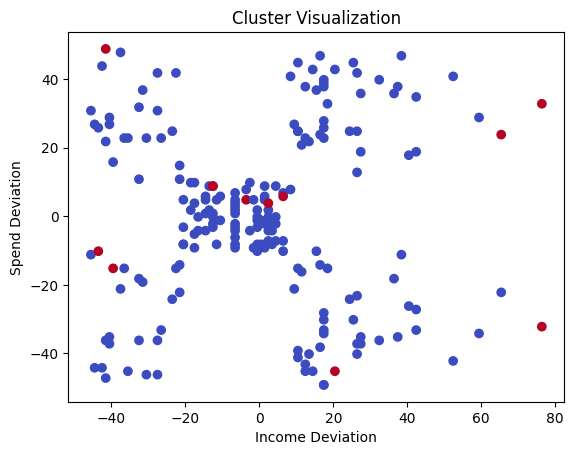

In [208]:
#Plot new output
plt.scatter(X_new["income_dev"], X_new["spend_dev"], c=preds_cluster, cmap='coolwarm')
plt.xlabel('Income Deviation')
plt.ylabel('Spend Deviation')
plt.title('Cluster Visualization')
plt.show()


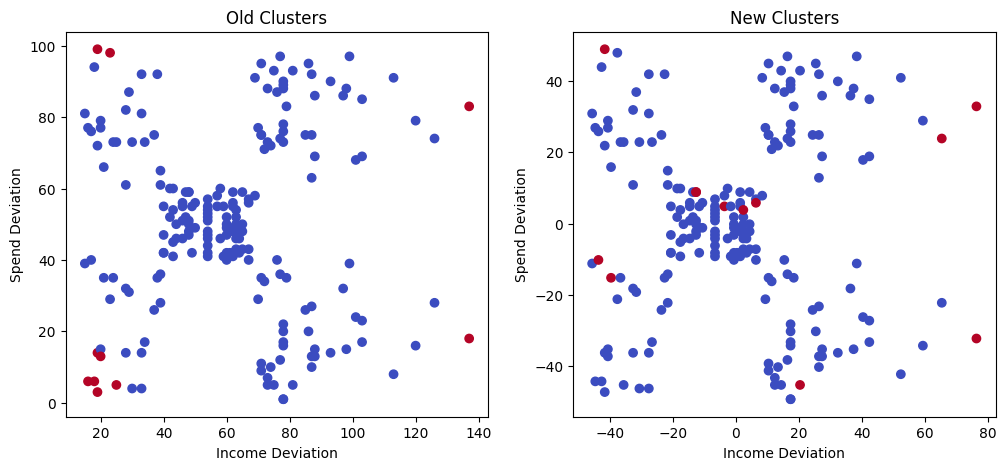

In [209]:
#Compare old vs new
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(X["Annual Income (k$)"], X["Spending Score (1-100)"], c = preds, cmap='coolwarm')
plt.xlabel('Income Deviation')
plt.ylabel('Spend Deviation')   
plt.title('Old Clusters')
plt.subplot(1,2,2)
plt.scatter(X_new["income_dev"], X_new["spend_dev"], c=preds_cluster, cmap='coolwarm')
plt.xlabel('Income Deviation')
plt.ylabel('Spend Deviation')
plt.title('New Clusters')
plt.show()

In [210]:
#Compute silhouette score for new clusters vs old clusters
score_new = silhouette_score(x_scaled_new, labels)
print("Old Silhouette Score:", score)
print("New Silhouette Score:", score_new)

Old Silhouette Score: 0.4039582785148566
New Silhouette Score: 0.4381779425805139
